# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices


## 1. Input unaligned slices (with paired images)


In [3]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt



NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
DEMO_DIR = PROJECT_ROOT / "demo"
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))

from roma import align_and_process_images

DATA_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_DATA_DIR", DEMO_DIR / "SPOmiAlign_Repro")
).expanduser()
SAVE_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")
).expanduser()
SAVE_PATH = SAVE_DIR / "img_2_img/S2toS1"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_PATH}")
img1_path = DATA_DIR / "output_image" / "E15_5-S1-HE.jpg"
img2_path = DATA_DIR / "output_image" / "E15_5-S2-HE_warped_rt15.png"

assert img1_path.exists(), f"Target image not found: {img1_path}"
assert img2_path.exists(), f"Source image not found: {img2_path}"

print(f"Target image: {img1_path}")
print(f"Source image: {img2_path}")


Data directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro
Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/S2toS1
Target image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/E15_5-S1-HE.jpg
Source image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_image/E15_5-S2-HE_warped_rt15.png


## 2. Imaging (Generation of spatial structural images, SSI)


In [4]:
print("This notebook starts from prepared image slices, so no additional SSI generation step is required.")


This notebook starts from prepared image slices, so no additional SSI generation step is required.


## 3. Sections matching and warpping


Using device: cuda:0


2026-04-13 00:19:29.444 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)


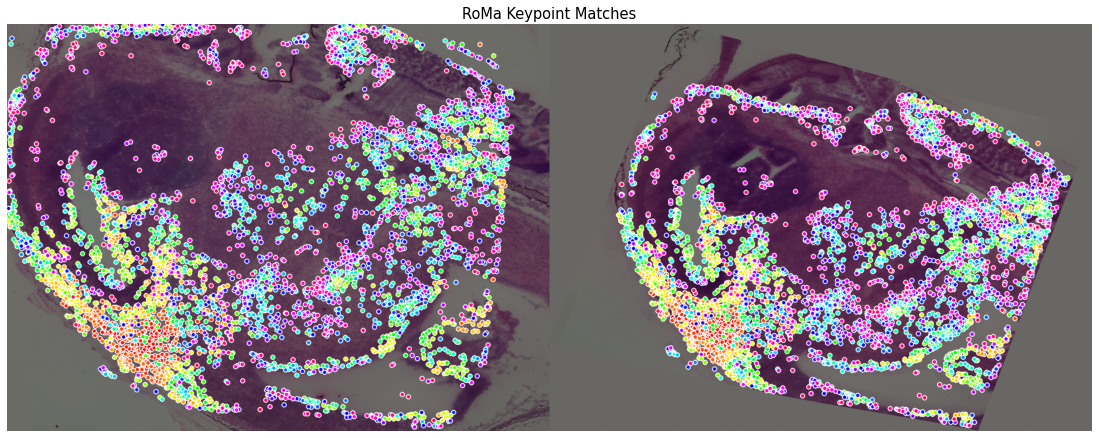

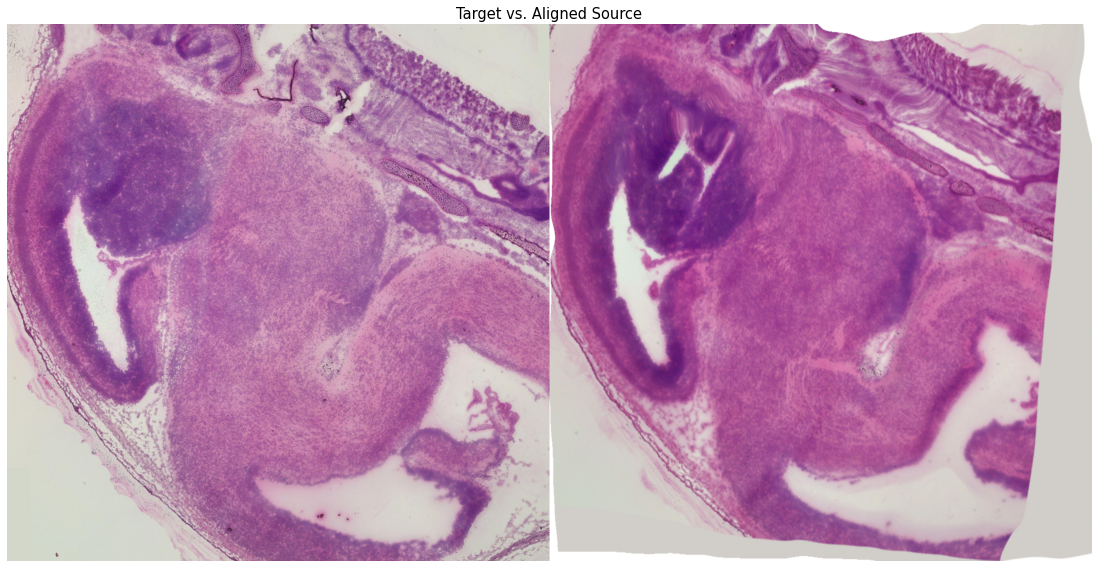

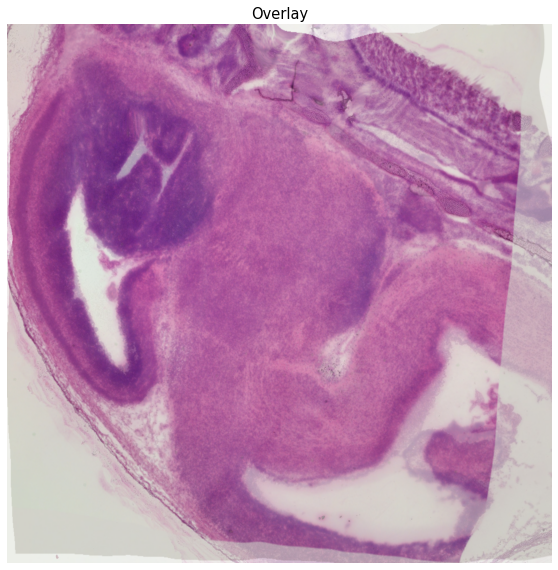

Alignment runtime: 5.8347 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/img_2_img/S2toS1/alignment


In [5]:
save_path_alignment = SAVE_PATH / "alignment"
save_path_alignment.mkdir(parents=True, exist_ok=True)
%matplotlib inline

align_and_process_images(
    img1_path=str(img1_path),
    img2_path=str(img2_path),
    method="affine+bspline",
    output_dir=str(save_path_alignment),
    rotate=0.0,
    scale=1.0,
)


## 4. Reassignment


In [6]:
print("Reassignment is not used in this notebook because it aligns images only.")


Reassignment is not used in this notebook because it aligns images only.


## 5. Output aligned slices


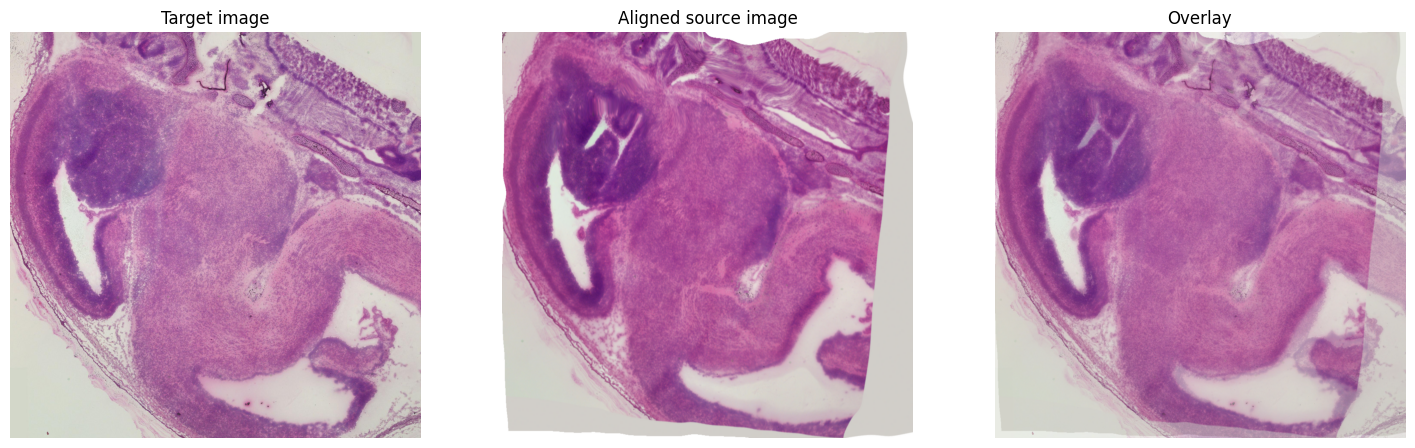

In [7]:
aligned_source_path = save_path_alignment / "aligned_source_img2.png"
assert aligned_source_path.exists(), f"Aligned source image not found: {aligned_source_path}"

target_img = cv2.imread(str(img1_path))
aligned_img = cv2.imread(str(aligned_source_path))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Target image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Aligned source image")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(cv2.addWeighted(target_img, 0.5, aligned_img, 0.5, 0), cv2.COLOR_BGR2RGB))
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.show()
